# 01 – Exploratory Data Analysis: Secondary Mushroom

**Worked on by:** Andreas Schellekens (set-up of the notebook, first exploration of all columns, statistical tests)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant). All findings and decisions were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup & loading

We import the libraries we use in this notebook and define the path to the data file.
The data file itself is **not** in git (see `.gitignore`); place the lecturer's CSV in `SecondaryMushroom/Data/`.
`LOKY_MAX_CPU_COUNT` silences a harmless joblib warning on Windows (used by the model in section 9); it must be set before scikit-learn is imported.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

DATA_PATH = Path("Data") / "mushroom_project_dataset.csv"
RANDOM_STATE = 42

# Colours used for the target in every plot, so the notebook reads consistently
CLASS_PALETTE = {"edible": "#2a9d8f", "poisonous": "#e76f51"}

We read the CSV exactly as it is. Empty cells become `NaN` by default.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")
df_raw.head()

Rows: 5,000  |  Columns: 13


,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e


## 2. First look & column names

`info()` shows the data type of every column and how many values are **not** missing.

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cap-diameter       2968 non-null   float64
 1   stem-height        3987 non-null   float64
 2   stem-width         4605 non-null   float64
 3   spore-print-color  260 non-null    object 
 4   gill-color         4011 non-null   object 
 5   habitat            3996 non-null   object 
 6   season             4027 non-null   object 
 7   ring-type          4423 non-null   object 
 8   cap-shape          4594 non-null   object 
 9   stem-surface       1641 non-null   object 
 10  jumbled_noise_0    4594 non-null   object 
 11  jumbled_noise_1    4594 non-null   object 
 12  class              5000 non-null   object 
dtypes: float64(3), object(10)
memory usage: 507.9+ KB


**Observations**
- 3 numerical columns (`cap-diameter`, `stem-height`, `stem-width`), 9 categorical columns and the target `class`.
- All categoricals are coded as single letters (see the UCI metadata). We translate them to readable labels so graphs and the future web interface are understandable.
- Column names contain dashes. We convert them to `snake_case`, which is easier to use in Python (`df.cap_diameter`) and in an API.
- Compared to the original UCI dataset (20 features) many columns are gone, and 2 new ones (`jumbled_noise_0/1`) were added. We investigate those in section 4.

Below: the code-to-label dictionaries, taken from the UCI description of the Secondary Mushroom dataset.

In [4]:
COLOR = {"n": "brown", "b": "buff", "g": "gray", "r": "green", "p": "pink", "u": "purple",
         "e": "red", "w": "white", "y": "yellow", "l": "blue", "o": "orange", "k": "black", "f": "none"}

CODE_MAPS = {
    "class":             {"e": "edible", "p": "poisonous"},
    "cap_shape":         {"b": "bell", "c": "conical", "x": "convex", "f": "flat",
                          "s": "sunken", "p": "spherical", "o": "others"},
    "gill_color":        COLOR,
    "spore_print_color": COLOR,
    "stem_surface":      {"i": "fibrous", "g": "grooves", "y": "scaly", "s": "smooth", "h": "shiny",
                          "l": "leathery", "k": "silky", "t": "sticky", "w": "wrinkled", "e": "fleshy", "f": "none"},
    "ring_type":         {"c": "cobwebby", "e": "evanescent", "r": "flaring", "g": "grooved", "l": "large",
                          "p": "pendant", "s": "sheathing", "z": "zone", "y": "scaly", "m": "movable", "f": "none"},
    "habitat":           {"g": "grasses", "l": "leaves", "m": "meadows", "p": "paths", "h": "heaths",
                          "u": "urban", "w": "waste", "d": "woods"},
    "season":            {"s": "spring", "u": "summer", "a": "autumn", "w": "winter"},
}
# The noise columns contain cap-shape codes (shown in section 4), so they get the same mapping
CODE_MAPS["jumbled_noise_0"] = CODE_MAPS["cap_shape"]
CODE_MAPS["jumbled_noise_1"] = CODE_MAPS["cap_shape"]

We make a working copy: rename the columns, translate the codes and check that **no code was left unmapped** (an unmapped code would silently become `NaN`, which would be a bug).

In [5]:
df = df_raw.copy()
df.columns = df.columns.str.strip().str.lower().str.replace("-", "_")

for col, mapping in CODE_MAPS.items():
    unknown = set(df[col].dropna().unique()) - set(mapping)
    assert not unknown, f"{col} has unmapped codes: {unknown}"
    df[col] = df[col].map(mapping)

NUM_COLS = ["cap_diameter", "stem_height", "stem_width"]
CAT_COLS = [c for c in df.columns if c not in NUM_COLS + ["class"]]
df[CAT_COLS + ["class"]] = df[CAT_COLS + ["class"]].astype("category")

print("Numerical:  ", NUM_COLS)
print("Categorical:", CAT_COLS)
df.head()

Numerical:   ['cap_diameter', 'stem_height', 'stem_width']
Categorical: ['spore_print_color', 'gill_color', 'habitat', 'season', 'ring_type', 'cap_shape', 'stem_surface', 'jumbled_noise_0', 'jumbled_noise_1']


,cap_diameter,stem_height,stem_width,spore_print_color,gill_color,habitat,season,ring_type,cap_shape,stem_surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,woods,summer,grooved,convex,NaN,convex,conical,poisonous
1,6.99,7.68,18.76,NaN,white,woods,autumn,none,flat,smooth,flat,flat,edible
2,5.78,7.67,8.21,NaN,green,woods,summer,none,conical,NaN,conical,convex,poisonous
3,6.34,8.34,11.06,NaN,NaN,woods,autumn,zone,convex,NaN,convex,bell,poisonous
4,NaN,5.67,12.78,NaN,brown,woods,NaN,none,convex,NaN,sunken,sunken,edible


**Note on the value `none`:** for `gill_color`, `stem_surface` and `ring_type` the code `f` means *"none"* (the mushroom has no gills / ring / stem surface). That is real information and **not** a missing value – we must keep it separate from `NaN`.

Duplicates: identical rows would give the model the same example twice (and could end up in both train and test set).

In [6]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


## 3. Target variable: `class`

Every mushroom is *edible* or *poisonous* (the UCI description says "unknown edibility" was merged into poisonous).
We check the balance, because that determines which metrics and which data split make sense.

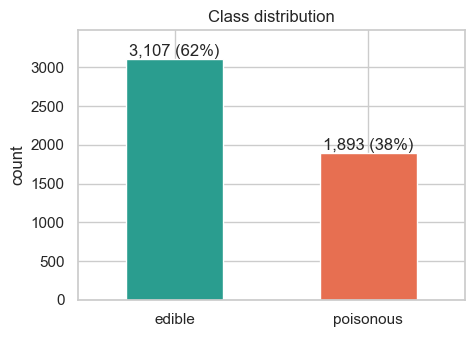

In [7]:
counts = df["class"].value_counts()
ax = counts.plot.bar(color=[CLASS_PALETTE[c] for c in counts.index], figsize=(5, 3.5), rot=0)
ax.bar_label(ax.containers[0], labels=[f"{n:,} ({n / len(df):.0%})" for n in counts])
ax.margins(y=0.12)  # headroom so the labels do not touch the title
ax.set(title="Class distribution", xlabel="", ylabel="count")
plt.show()

**Observations**
- 62% edible vs. 38% poisonous: mildly imbalanced, no resampling strictly needed, but we will use a **stratified** train/test split so both sets keep this ratio.
- Accuracy alone is misleading here: always predicting "edible" already gives 62%. That is our **naive baseline**.
- The two errors are **not equally bad**: calling a poisonous mushroom edible can be deadly, the opposite only costs a meal. For modelling we should therefore focus on **recall of the poisonous class** (and/or precision of "edible"), not just accuracy. This is an important "why" for the presentation.

## 4. The `jumbled_noise` columns

Two columns have suspicious names. Hypothesis: they are deliberately added noise features that have nothing to do with the target.
First we compare their value distribution with `cap_shape`.

In [8]:
pd.concat({c: df[c].value_counts(dropna=False) for c in ["cap_shape", "jumbled_noise_0", "jumbled_noise_1"]}, axis=1)

,cap_shape,jumbled_noise_0,jumbled_noise_1
convex,2060,2060,2060
flat,1078,1078,1078
sunken,533,533,533
NaN,406,406,406
bell,354,354,354
others,218,218,218
spherical,207,207,207
conical,144,144,144


The three columns have **exactly the same value counts** (including 406 missing). So the noise columns are copies of `cap_shape` whose rows were shuffled.
If they were really shuffled, the value in a given row should agree with `cap_shape` only by chance:

In [9]:
p = df["cap_shape"].value_counts(normalize=True)
expected_agreement = (p ** 2).sum()  # chance that two random draws from this distribution are equal
for c in ["jumbled_noise_0", "jumbled_noise_1"]:
    both_known = df[c].notna() & df["cap_shape"].notna()
    observed = (df.loc[both_known, c] == df.loc[both_known, "cap_shape"]).mean()
    print(f"{c}: agrees with cap_shape in {observed:.1%} of rows (pure chance would give ~{expected_agreement:.1%})")

jumbled_noise_0: agrees with cap_shape in 28.3% of rows (pure chance would give ~28.1%)
jumbled_noise_1: agrees with cap_shape in 27.8% of rows (pure chance would give ~28.1%)


Agreement is at chance level → the rows were shuffled. Now the key question: **is there any relation with the target?**

We use the **chi-squared test of independence** on the contingency table feature × class.
- H0: feature and class are independent.
- A small p-value (< 0.05) means we reject H0.

The p-value only says *whether* there is a relation, not *how strong*. For strength we use **Cramér's V** (0 = no association, 1 = perfect). We use the bias-corrected version, because the plain one is inflated for small samples.
Missing values are included as their own category (`"missing"`), because missingness itself could carry information.

In [10]:
def cramers_v(x, y):
    """Bias-corrected Cramér's V between two categorical series (Bergsma, 2013)."""
    table = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / max(1e-12, min(k_corr - 1, r_corr - 1)))


def with_missing(s):
    """Treat NaN as an explicit category so it is part of the test."""
    return s.astype("object").fillna("missing")


def cat_vs_target(cols):
    rows = []
    for c in cols:
        x = with_missing(df[c])
        p_value = stats.chi2_contingency(pd.crosstab(x, df["class"]))[1]
        rows.append({"feature": c, "p_value": p_value, "cramers_v": cramers_v(x, df["class"])})
    return pd.DataFrame(rows).set_index("feature")


cat_vs_target(["cap_shape", "jumbled_noise_0", "jumbled_noise_1"]).style.format({"p_value": "{:.2e}", "cramers_v": "{:.3f}"})

,p_value,cramers_v
feature,,
cap_shape,2.95e-26,0.161
jumbled_noise_0,5.61e-01,0.000
jumbled_noise_1,1.33e-02,0.046


**Interpretation**
- `cap_shape` has a clear relation with the class (tiny p-value, V ≈ 0.16).
- `jumbled_noise_0`: p ≈ 0.56 → no evidence of any relation.
- `jumbled_noise_1`: p ≈ 0.013 looks "significant" at 5%. **But** we run many tests in this notebook. With 10+ tests at α = 0.05, one false positive is to be expected. With a Bonferroni correction (α / number of tests ≈ 0.05 / 12 ≈ 0.004) it is no longer significant, and Cramér's V is close to 0. This is a nice example of a **misleading statistic**.

**Decision:** drop `jumbled_noise_0` and `jumbled_noise_1`. They are shuffled copies with no real link to the target; keeping them only gives the model a chance to overfit on noise.
*(Optional check in the modelling phase: train once with and once without them and show that the validation score does not drop.)*

In [11]:
df = df.drop(columns=["jumbled_noise_0", "jumbled_noise_1"])
CAT_COLS = [c for c in CAT_COLS if not c.startswith("jumbled_noise")]

## 5. Missing values

### 5.1 How much is missing?

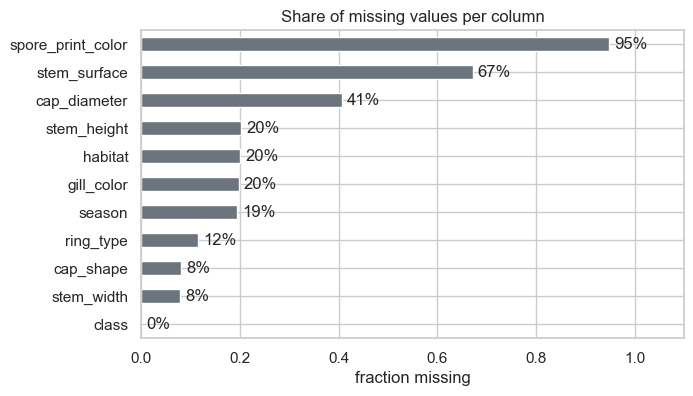

In [12]:
missing = df.isna().mean().sort_values(ascending=False)
ax = missing.plot.barh(figsize=(7, 4), color="#6c757d")
for y, v in enumerate(missing):
    ax.text(v + 0.01, y, f"{v:.0%}", va="center")
ax.set(title="Share of missing values per column", xlabel="fraction missing", xlim=(0, 1.1))
ax.invert_yaxis()
plt.show()

**Observations**
- `spore_print_color` is 95% empty and `stem_surface` 67%. Imputing 95% of a column means *inventing* nearly all of it.
- `cap_diameter` is missing in 41% of rows – a lot for what is probably an important feature.
- The target `class` is never missing.

### 5.2 Are values missing at random?
It matters *why* a value is missing:
- **MCAR** (missing completely at random): missingness has nothing to do with anything → simple imputation is fine.
- **MNAR/MAR**: missingness depends on the class or on other features → the *fact* that a value is missing is information, and a model could use a "missing" flag.

We test for each column whether the share of poisonous mushrooms differs between rows where the value is missing and rows where it is present (chi-squared test on a 2×2 table).

In [13]:
rows = []
for c in df.columns.drop("class"):
    is_missing = df[c].isna()
    if is_missing.sum() == 0:
        continue
    table = pd.crosstab(is_missing, df["class"])
    rows.append({
        "feature": c,
        "missing_%": is_missing.mean() * 100,
        "%_poisonous_when_present": (df.loc[~is_missing, "class"] == "poisonous").mean() * 100,
        "%_poisonous_when_missing": (df.loc[is_missing, "class"] == "poisonous").mean() * 100,
        "p_value": stats.chi2_contingency(table)[1],
    })
missing_vs_class = pd.DataFrame(rows).set_index("feature").sort_values("p_value")
missing_vs_class.style.format("{:.1f}", subset=missing_vs_class.columns[:-1]).format("{:.2e}", subset=["p_value"])

,missing_%,%_poisonous_when_present,%_poisonous_when_missing,p_value
feature,,,,
stem_surface,67.2,42.8,35.5,6.32e-07
spore_print_color,94.8,48.8,37.3,2.28e-04
habitat,20.1,37.3,40.2,8.87e-02
cap_shape,8.1,38.0,35.7,3.81e-01
ring_type,11.5,38.1,36.2,4.14e-01
cap_diameter,40.6,37.5,38.3,5.86e-01
season,19.5,37.7,38.6,6.00e-01
stem_width,7.9,37.9,37.0,7.42e-01
gill_color,19.8,37.8,38.1,8.80e-01


**Interpretation** (keep the Bonferroni idea from section 4 in mind: threshold ≈ 0.05 / 10 = 0.005)
- Only `stem_surface` and `spore_print_color` have missingness that is clearly **related to the class**: when they are missing, the mushroom is *less* often poisonous. These two columns were already largely empty in the original UCI data (a species simply has no recorded value), so their missingness says something about the *species*. For them, a missing value is a **signal** → keep it as an explicit `"missing"` category.
- For all other columns (all three numericals included) the p-value is large: the share of poisonous mushrooms is the same whether the value is known or not. That looks like **random deletion (MCAR)** – exactly what you'd expect if cells were blanked out at random to make the dataset harder. Simple imputation is fine there, and a missing-indicator would add nothing.

### 5.3 Do values go missing together?
If the same rows miss many values, those rows are hard to predict. We look at the correlation between the *missingness* of columns and at how many values a row is missing.

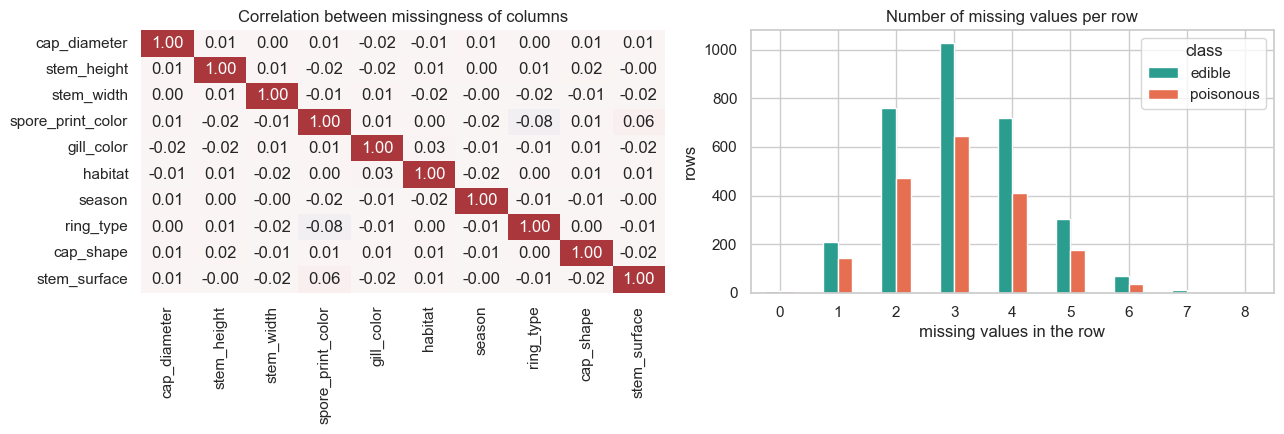

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

miss_corr = df.drop(columns="class").isna().astype(int).corr()
sns.heatmap(miss_corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Correlation between missingness of columns")

n_missing = df.drop(columns="class").isna().sum(axis=1)
pd.crosstab(n_missing, df["class"]).plot.bar(ax=axes[1], color=CLASS_PALETTE, rot=0)
axes[1].set(title="Number of missing values per row", xlabel="missing values in the row", ylabel="rows")
plt.tight_layout()
plt.show()

**Observations**
- Missingness correlations are all close to 0 (max ≈ 0.08) → values were removed independently per column, there are no "blocks" of columns that disappear together.
- Most rows miss 2–4 values; only **12 of the 5000 rows** are complete. Dropping rows with a missing value (`dropna()`) is therefore **not an option** – we would lose almost the whole dataset, and the assignment explicitly says to use every row optimally.

**Implications for data preparation**
- Never drop rows for missing values; impute instead.
- Categoricals: add an explicit `"missing"` category (works for every model, and lets the model use informative missingness).
- Numericals: missing at random → impute with the median (robust to outliers), **fitted on the training set only** (to avoid data leakage). In section 8 we'll see that `cap_diameter` (41% missing!) is strongly correlated with `stem_width`, so a model-based imputer (`IterativeImputer` / `KNNImputer`) is a promising experiment.
- `spore_print_color` (95% missing): keep only as *"present / missing"* information or drop – to decide by comparing models.

## 6. Numerical features & outliers

### 6.1 Summary statistics

In [15]:
df[NUM_COLS].describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
cap_diameter,2968.00,7.16,5.99,0.50,3.83,6.14,8.79,57.40
stem_height,3987.00,6.69,3.45,0.00,4.80,6.01,7.74,32.43
stem_width,4605.00,12.89,10.61,0.00,5.94,11.28,17.05,102.48


All three are in **centimetres** (cap diameter) or **millimetres** (stem height/width), according to UCI. Two things stand out:
- The **max** is far above the 75th percentile (e.g. cap diameter 57 cm vs. 75% ≤ 8.8 cm) → right-skewed distributions with a long tail.
- `stem_height` and `stem_width` have a **minimum of 0**. A stem of 0 could be an error, or it could be a real mushroom *without a stem* (e.g. bracket fungi growing on trees).

In [16]:
zero_h, zero_w = df["stem_height"] == 0, df["stem_width"] == 0
print("stem_height == 0:", zero_h.sum(), "| stem_width == 0:", zero_w.sum(), "| both 0:", (zero_h & zero_w).sum())
print("\nstem_width for rows with stem_height == 0:")
print(df.loc[zero_h, "stem_width"].value_counts(dropna=False).head())
print("\nClass of mushrooms with a stem of height 0:")
print(df.loc[zero_h, "class"].value_counts())

stem_height == 0: 49 | stem_width == 0: 57 | both 0: 46

stem_width for rows with stem_height == 0:
stem_width
0.0    46
NaN     3
Name: count, dtype: int64

Class of mushrooms with a stem of height 0:
class
poisonous    45
edible        4
Name: count, dtype: int64


**Interpretation**
- Every row with height 0 has width 0 as well (or width missing) → the zeros are **consistent**: they describe mushrooms *without a stem*, not measurement errors. We keep them as valid values.
- 45 of the 49 stemless mushrooms are poisonous (92% vs. 38% overall)! "Has no stem" is a strong signal. Candidate engineered feature: `has_stem = stem_height > 0`, which also stays usable when only one of the two measures is known.

### 6.2 Distributions per class

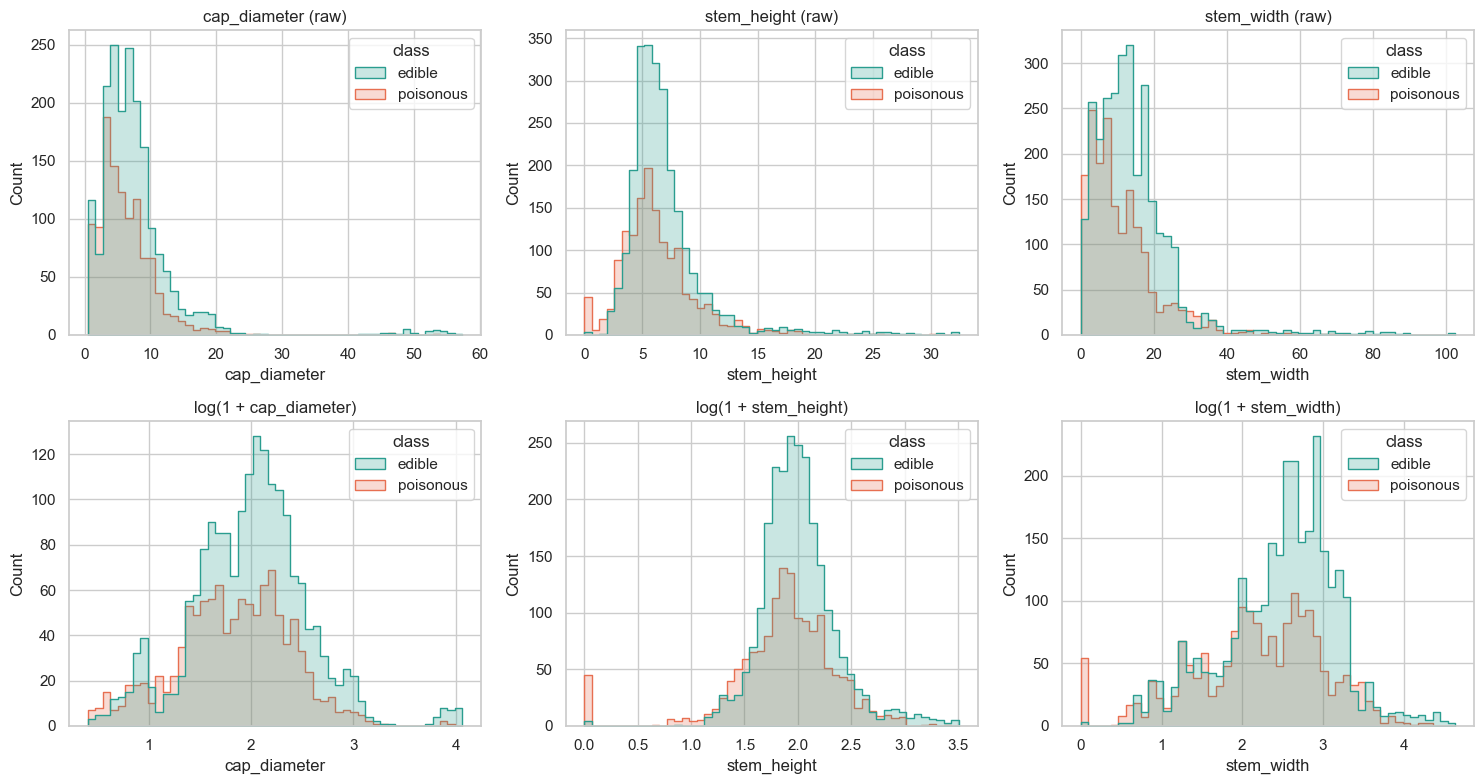

Skewness raw:   {'cap_diameter': 4.23, 'stem_height': 2.46, 'stem_width': 2.6}
Skewness log1p: {'cap_diameter': 0.1, 'stem_height': -0.76, 'stem_width': -0.52}


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(NUM_COLS):
    sns.histplot(data=df, x=col, hue="class", palette=CLASS_PALETTE, bins=50, element="step", ax=axes[0, i])
    axes[0, i].set_title(f"{col} (raw)")
    sns.histplot(data=df.assign(**{col: np.log1p(df[col])}), x=col, hue="class", palette=CLASS_PALETTE,
                 bins=50, element="step", ax=axes[1, i])
    axes[1, i].set_title(f"log(1 + {col})")
plt.tight_layout()
plt.show()

print("Skewness raw:  ", df[NUM_COLS].skew().round(2).to_dict())
print("Skewness log1p:", np.log1p(df[NUM_COLS]).skew().round(2).to_dict())

**Observations**
- The raw distributions are strongly right-skewed. After `log1p` (log(1+x), which also works for 0) they look much more symmetric.
- **For tree-based models** (Random Forest, XGBoost, …) this doesn't matter – they only look at the order of values.
- **For distance- or linear models** (logistic regression, KNN, SVM) a log transform + scaling will probably help. We keep this in mind for the model notebooks.

### 6.3 Outliers
Classic rule (Tukey): a value is an outlier if it lies more than 1.5 × IQR below Q1 or above Q3. We count these and look at them per class.

In [18]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    return q1 - k * (q3 - q1), q3 + k * (q3 - q1)

rows = []
for col in NUM_COLS:
    low, high = iqr_bounds(df[col])
    is_out = (df[col] < low) | (df[col] > high)
    rows.append({"feature": col, "upper_bound": high, "n_outliers": is_out.sum(),
                 "%_of_known": is_out.sum() / df[col].notna().sum() * 100,
                 "%_poisonous_among_outliers": (df.loc[is_out, "class"] == "poisonous").mean() * 100})
pd.DataFrame(rows).set_index("feature").style.format("{:.1f}")

,upper_bound,n_outliers,%_of_known,%_poisonous_among_outliers
feature,,,,
cap_diameter,16.2,134.0,4.5,20.9
stem_height,12.2,271.0,6.8,46.5
stem_width,33.7,164.0,3.6,28.7


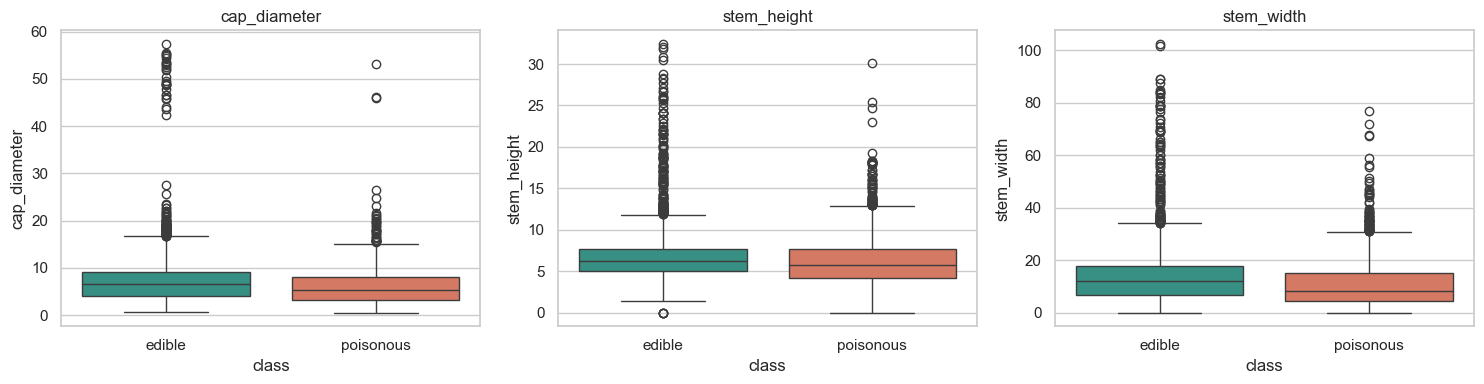

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(data=df, x="class", y=col, hue="class", palette=CLASS_PALETTE, ax=ax, legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Interpretation**
- Several percent of the values fall outside the IQR bounds, but that is expected for skewed data – the IQR rule assumes a roughly symmetric distribution.
- The large values are **biologically plausible** (some mushroom species really have a cap of 30–60 cm; stems of 10 cm wide exist).
- The outliers are not all one class, so they are not a hidden label. Interesting though: among the very large caps only 21% are poisonous (vs. 38% overall) – large caps lean edible.

**Decision:** we do **not** remove outliers. Removing ~5–10% of an already small dataset loses information, and the extremes are plausible. We handle the skew with a log transform (for models that need it) instead. If a value is physically impossible (negative size) we would remove it – there are none.

### 6.4 Do the numerical features differ between the classes?
The distributions are not normal, so a t-test is not appropriate. We use the **Mann-Whitney U test** (non-parametric: compares whether values in one group tend to be larger than in the other).
As effect size we report the **rank-biserial correlation** r (−1 … 1; |r| ≈ 0.1 small, 0.3 medium, 0.5 large).

In [20]:
rows = []
for col in NUM_COLS:
    ed = df.loc[df["class"] == "edible", col].dropna()
    po = df.loc[df["class"] == "poisonous", col].dropna()
    u, p_value = stats.mannwhitneyu(ed, po, alternative="two-sided")
    rows.append({"feature": col, "median_edible": ed.median(), "median_poisonous": po.median(),
                 "p_value": p_value, "rank_biserial_r": 1 - 2 * u / (len(ed) * len(po))})
pd.DataFrame(rows).set_index("feature").style.format("{:.3f}").format("{:.2e}", subset=["p_value"])

,median_edible,median_poisonous,p_value,rank_biserial_r
feature,,,,
cap_diameter,6.555,5.330,1.12e-13,-0.163
stem_height,6.190,5.725,1.73e-11,-0.127
stem_width,12.265,8.420,8.90e-32,-0.206


**Interpretation:** for all three measures poisonous mushrooms are on average *smaller* (lower median), and the difference is highly significant. But the effect sizes are small (|r| ≈ 0.13–0.21): the distributions overlap a lot. A significant p-value with a small |r| means the difference is real but on its own not very useful for prediction. The numerical features will likely help mostly *in combination* with the categoricals (which a tree model can learn).

## 7. Categorical features

### 7.1 Share of poisonous mushrooms per category
For every categorical feature we show, per category, how many mushrooms there are (bar width = count) and what fraction is poisonous.
The dashed line is the overall share of poisonous mushrooms (38%). Categories far from that line are informative.

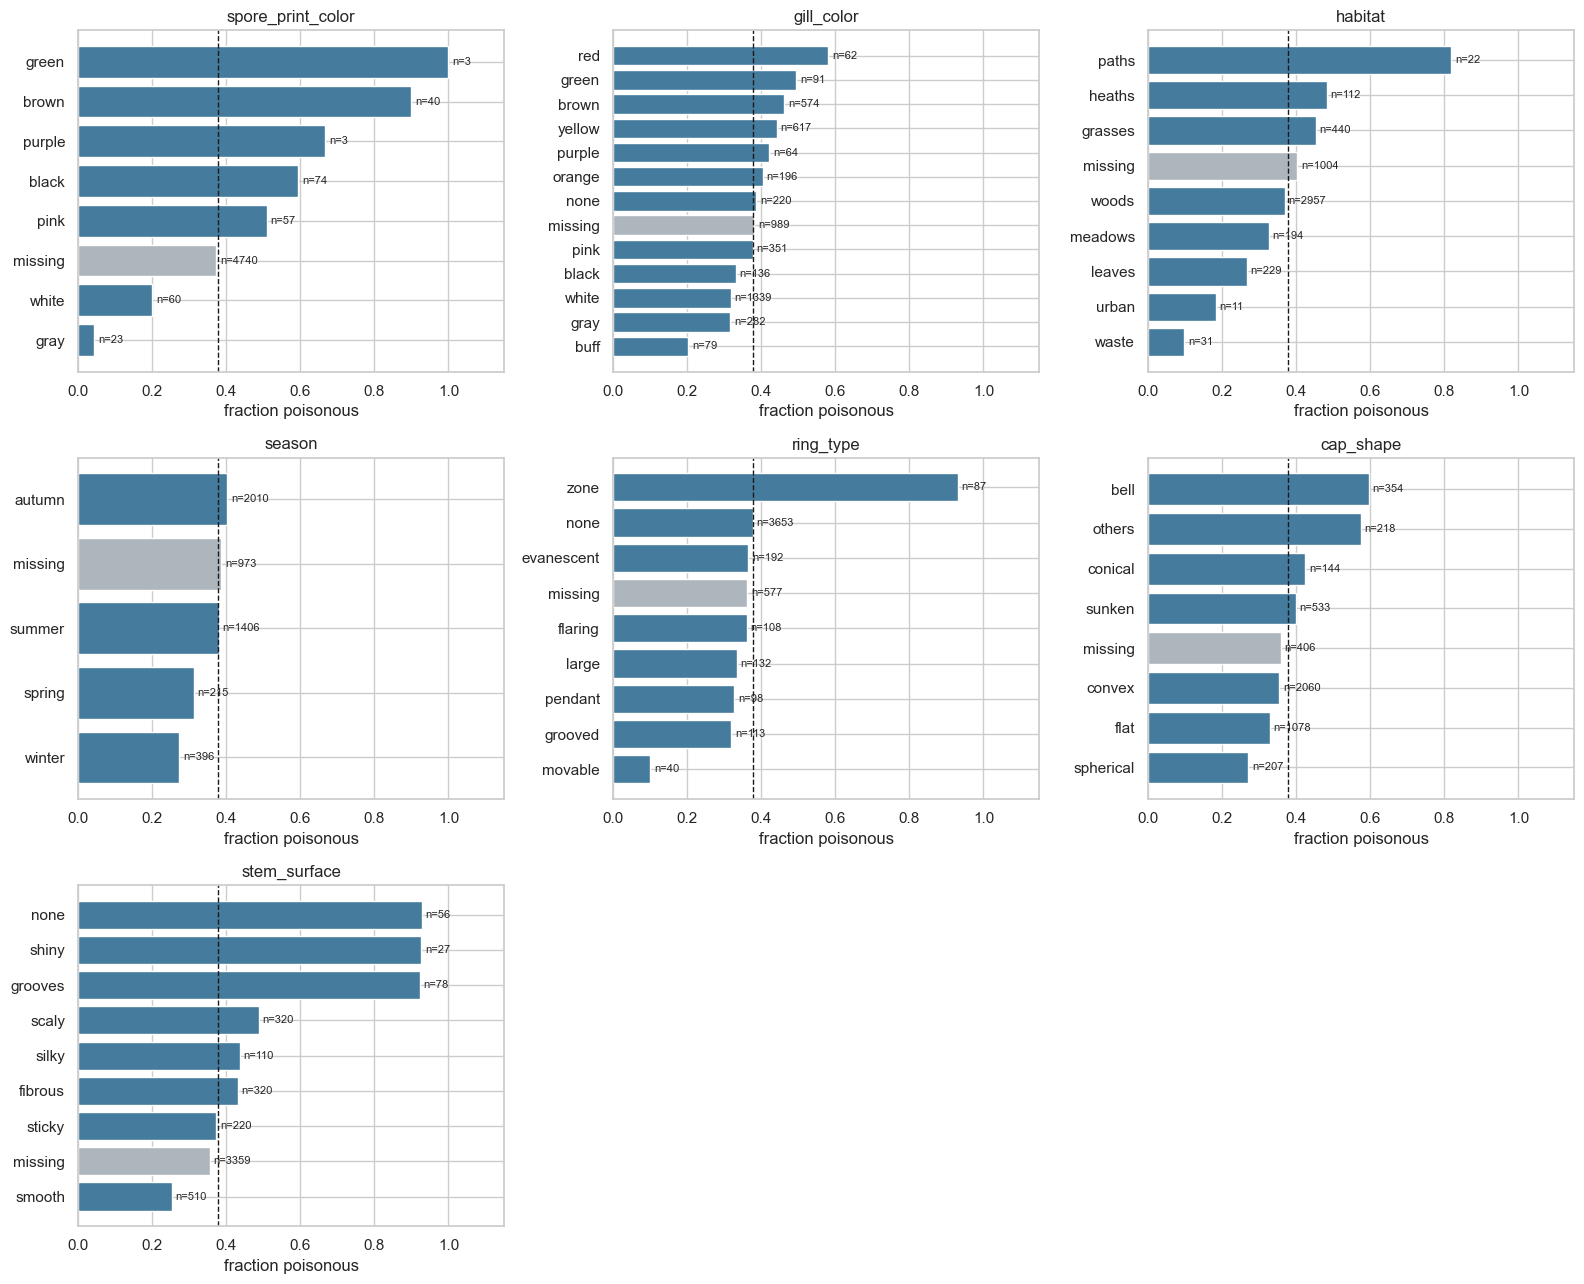

In [21]:
overall_poison = (df["class"] == "poisonous").mean()

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, col in zip(axes.flat, CAT_COLS):
    x = with_missing(df[col])
    summary = (pd.DataFrame({"x": x, "poison": df["class"] == "poisonous"})
               .groupby("x")["poison"].agg(["mean", "size"]).sort_values("mean"))
    colors = ["#adb5bd" if i == "missing" else "#457b9d" for i in summary.index]
    ax.barh(summary.index, summary["mean"], color=colors)
    for y, (m, n) in enumerate(summary.values):
        ax.text(m + 0.01, y, f"n={int(n)}", va="center", fontsize=8)
    ax.axvline(overall_poison, ls="--", c="k", lw=1)
    ax.set(title=col, xlim=(0, 1.15), xlabel="fraction poisonous")
for ax in axes.flat[len(CAT_COLS):]:
    ax.remove()
plt.tight_layout()
plt.show()

**Observations**
- A few categories are (almost) pure and are strong signals for a model:
  - `ring_type = zone` → 93% poisonous (n=87); `ring_type = movable` → 10% (n=40)
  - `stem_surface = grooves / shiny / none` → 92–93% poisonous
  - `habitat = paths` → 82% poisonous; `habitat = waste` → 10%
  - `spore_print_color = brown` → 90% poisonous; `= gray` → 4%
  - `cap_shape = bell / others` → ~60% poisonous
- But most of the data sits in large categories close to the dashed line (e.g. `ring_type = none` has 3653 rows at 38%): for the bulk of the mushrooms no single feature is decisive.
- Many categories are **rare** (n < 30, e.g. spore colours purple/green with n=3). Their fraction is unreliable (a few flipped labels can change it a lot) and one-hot encoding them creates sparse columns. Option for data preparation: group rare categories into `"other"`.
- The grey `"missing"` bar of `stem_surface` is clearly below the line – confirming section 5.2.

### 7.2 Which categorical features are most related to the class?
Same test as in section 4 (chi-squared + Cramér's V), now for all categoricals. Missing is kept as a category.

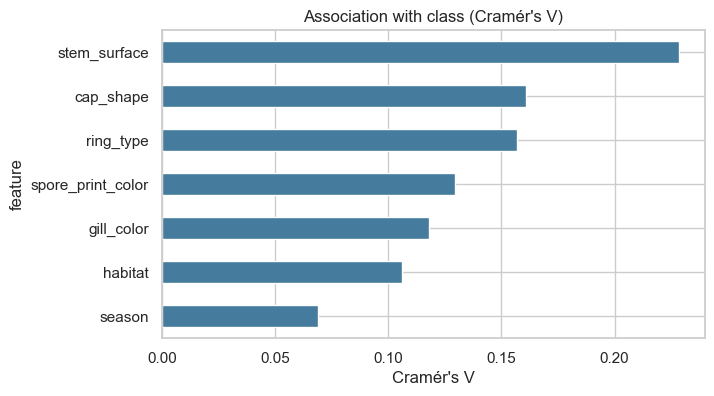

,p_value,cramers_v,significant_bonferroni
feature,,,
stem_surface,1.92e-53,0.228,True
cap_shape,2.95e-26,0.161,True
ring_type,1.71e-24,0.157,True
spore_print_color,8.35e-17,0.129,True
gill_color,1.83e-12,0.118,True
habitat,7.58e-11,0.106,True
season,1.31e-05,0.069,True


In [22]:
cat_assoc = cat_vs_target(CAT_COLS).sort_values("cramers_v", ascending=False)
n_tests = len(cat_assoc)
cat_assoc["significant_bonferroni"] = cat_assoc["p_value"] < 0.05 / n_tests

ax = cat_assoc["cramers_v"].plot.barh(figsize=(7, 4), color="#457b9d")
ax.invert_yaxis()
ax.set(title="Association with class (Cramér's V)", xlabel="Cramér's V")
plt.show()
cat_assoc.style.format({"p_value": "{:.2e}", "cramers_v": "{:.3f}"})

**Interpretation:** all remaining categoricals are significantly related to the class, even after Bonferroni correction. Individually the associations are **weak** (V between 0.07 for `season` and 0.23 for `stem_surface`). No single feature predicts edibility on its own – which is also biologically true (there is no simple rule to tell edible from poisonous mushrooms!). A good model will need to combine features.

### 7.3 Ordered categoricals?
The assignment asks to consider ordered categoricals. None of the remaining features has a natural order:
- colours, shapes, surfaces, ring types, habitats → nominal.
- `season` has an order in time, but it is **cyclic** (winter → spring), so encoding it as 1–4 would wrongly suggest that winter is "far" from spring. We treat it as nominal (one-hot).

So we use one-hot encoding (or native categorical support in e.g. LightGBM/CatBoost) rather than ordinal encoding.

## 8. Relations between features

Strongly related features give the model redundant information (and make interpretation of e.g. logistic regression coefficients unreliable).
- Numerical ↔ numerical: **Spearman** correlation (rank-based, robust to skew and outliers).
- Categorical ↔ categorical: **Cramér's V**.

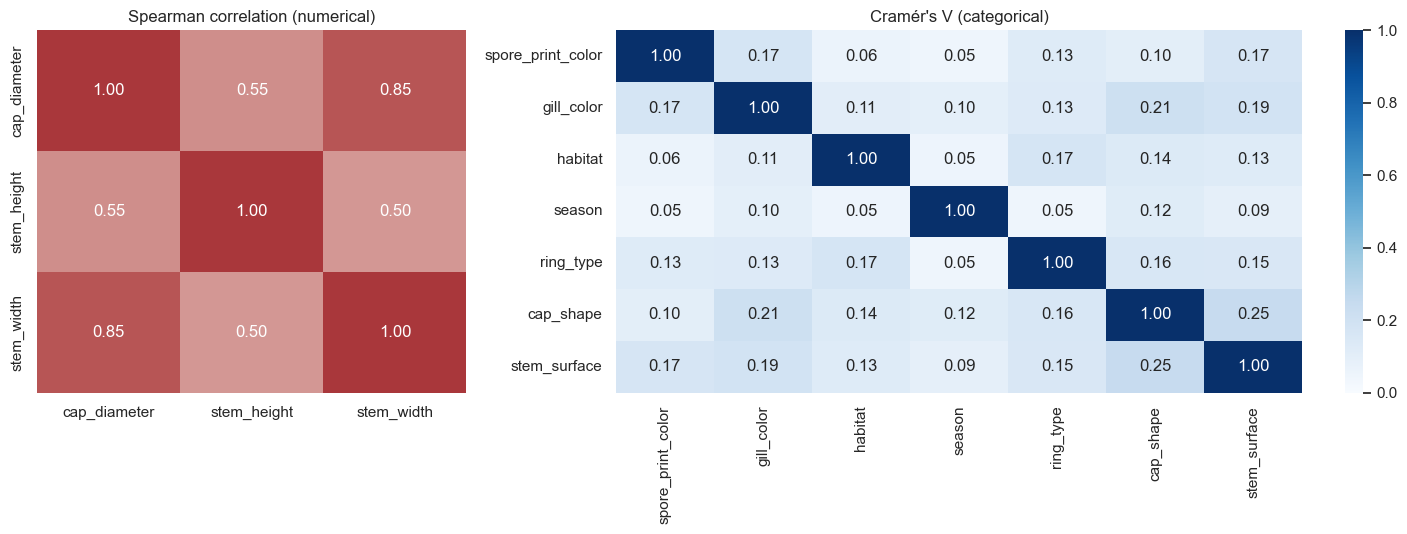

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1, 2]})

sns.heatmap(df[NUM_COLS].corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag",
            center=0, vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Spearman correlation (numerical)")

v = pd.DataFrame([[cramers_v(with_missing(df[a]), with_missing(df[b])) for b in CAT_COLS] for a in CAT_COLS],
                 index=CAT_COLS, columns=CAT_COLS)
sns.heatmap(v, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Cramér's V (categorical)")
plt.tight_layout()
plt.show()

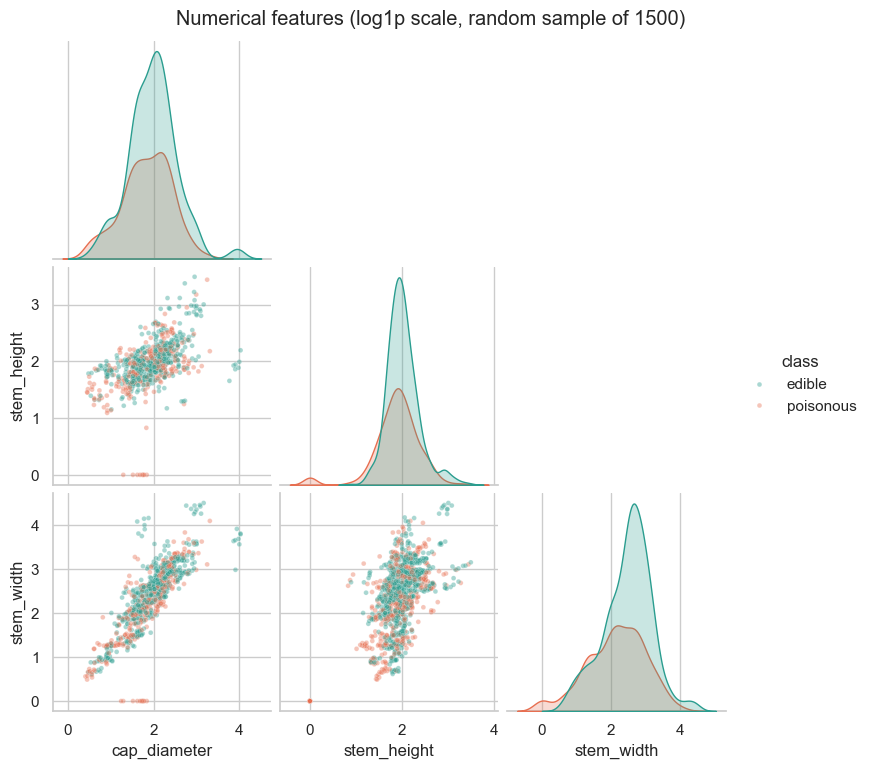

In [24]:
sns.pairplot(df[NUM_COLS + ["class"]].sample(1500, random_state=RANDOM_STATE).assign(
                 **{c: lambda d, c=c: np.log1p(d[c]) for c in NUM_COLS}),
             hue="class", palette=CLASS_PALETTE, plot_kws={"alpha": 0.4, "s": 12}, corner=True)
plt.suptitle("Numerical features (log1p scale, random sample of 1500)", y=1.02)
plt.show()

**Observations**
- The three size measures are positively correlated (bigger mushrooms have bigger caps *and* thicker stems). `cap_diameter` ↔ `stem_width` is strong (ρ ≈ 0.85). We keep both (tree models don't suffer from correlated features, and they aren't identical), but it is **useful for imputation**: 41% of `cap_diameter` is missing, and `stem_width` is known in most of those rows.
- The categoricals are only weakly related to each other (V ≤ 0.25) → little redundancy, every feature adds some information.
- In the pairplot the classes overlap a lot: no simple straight line separates them → we expect **non-linear models** (trees, boosting) to do better than linear ones.
- The strongly correlated measures suggest ratio features for feature engineering later, e.g. `stem_width / stem_height` (a "shape" of the stem independent of size).

## 9. Label noise

The assignment says some class labels *may or may not* have been flipped. We can't see this directly, but we can look for clues.

**Idea:** train a quick model with 5-fold cross-validation and get an *out-of-fold* probability for every row – i.e. a prediction made by a model that **never saw that row**. If the model is very confident that a row belongs to the *other* class than its label, that row is a candidate for a flipped label (or a genuinely unusual mushroom).

We use `HistGradientBoostingClassifier` because it handles missing values and categorical features natively, so no cleaning is needed for this diagnostic. This is **not** our baseline model (that comes in the model notebooks with a proper train/test split); it's only a tool to look at the data.

Out-of-fold accuracy of the diagnostic model: 79.5%


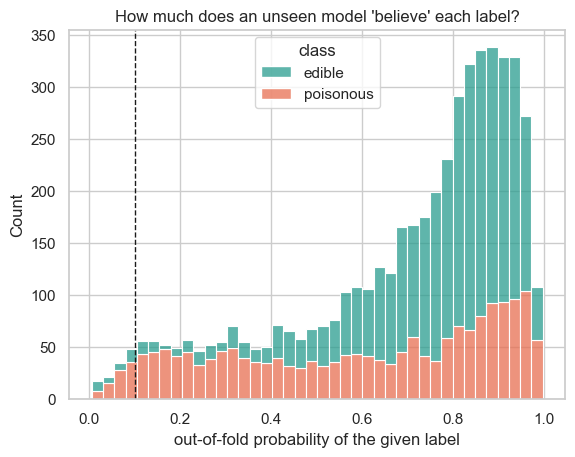

Rows where the model gives < 10% to the given label: 108 (2.2%)
class
poisonous    78
edible       30


In [25]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

X_diag = df.drop(columns="class")
y_diag = (df["class"] == "poisonous").astype(int)

diag_model = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
p_poison = cross_val_predict(diag_model, X_diag, y_diag, cv=cv, method="predict_proba")[:, 1]

# Probability the model assigns to the label that is actually in the data
p_given_label = np.where(y_diag == 1, p_poison, 1 - p_poison)
print(f"Out-of-fold accuracy of the diagnostic model: {((p_poison > 0.5) == y_diag).mean():.1%}")

ax = sns.histplot(x=p_given_label, hue=df["class"], palette=CLASS_PALETTE, bins=40, multiple="stack")
ax.axvline(0.1, ls="--", c="k", lw=1)
ax.set(title="How much does an unseen model 'believe' each label?", xlabel="out-of-fold probability of the given label")
plt.show()

suspect = p_given_label < 0.1
print(f"Rows where the model gives < 10% to the given label: {suspect.sum()} ({suspect.mean():.1%})")
print(df.loc[suspect, "class"].value_counts().to_string())

**Interpretation**
- Even a default model without tuning or cleaning gets far above the 62% baseline – there is a real, learnable signal.
- But it is also far from the ~100% the original UCI dataset allows. Part of that is lost information (fewer features, many missing values), part may be flipped labels.
- About 2% of the rows get less than 10% probability for their own label. Most of them are labelled *poisonous* while the model strongly believes *edible*. These are the suspects. We can't prove they are flipped – they could also be poisonous species that look like edible ones (which is exactly why mushroom picking is dangerous).

**What this means for modelling**
- Label noise puts a **ceiling** on the achievable accuracy.
- Models that fit every training example perfectly (very deep trees, 1-NN) will memorise flipped labels → regularisation and cross-validation are needed.
- Possible extension: remove or down-weight suspect rows **in the training set only** and check whether the **validation** score improves. The test set must stay untouched, otherwise we'd be fooling ourselves.
- For safety we should **not** remove "poisonous" labels just because the model disagrees: a wrong *poisonous* label costs a meal, a wrong *edible* label can cost a life.

## 10. Conclusions & decisions for data preparation

### What the data tells us
1. **Target:** 62% edible / 38% poisonous. Naive baseline accuracy = 62%. The costly error is predicting *edible* for a *poisonous* mushroom → focus on recall of the poisonous class.
2. **Noise columns:** `jumbled_noise_0/1` are shuffled copies of `cap_shape` with no relation to the target (the one "significant" p-value disappears after correcting for multiple tests).
3. **Missing values** are everywhere; almost no row is complete. They were removed independently per column, and for some columns missingness is related to the class.
   Only for `stem_surface` and `spore_print_color` is missingness related to the class; elsewhere it looks random.
4. **Numerical features** are right-skewed with plausible extremes. Poisonous mushrooms are slightly smaller. Zeros in the stem measures mean "no stem" – and stemless mushrooms are 92% poisonous.
5. **All categoricals** are significantly but only weakly related to the class. A few rare categories are nearly pure (ring type *zone*, stem surface *grooves/shiny/none*, habitat *paths*), but for most mushrooms no single feature decides edibility. Features must be combined → non-linear models.
6. **Label noise** probably exists: a quick diagnostic model gets ~80% out-of-fold, with ~2% of rows strongly contradicting their label.

### Cleaning steps for `02_data_preparation.ipynb`
| # | Step | Reason |
|---|---|---|
| 1 | Rename columns to `snake_case` | Consistent, API-friendly names |
| 2 | Translate letter codes to readable labels | Understandable plots & web interface |
| 3 | Drop `jumbled_noise_0`, `jumbled_noise_1` | Pure noise (section 4) |
| 4 | Keep all rows, do **not** drop NaN rows | Almost every row has a missing value |
| 5 | Categorical NaN → `"missing"` category | Informative for `stem_surface`/`spore_print_color`, harmless elsewhere (5.2) |
| 6 | Numerical NaN → median imputation, fit on train only | Missing at random, robust to skew, no leakage (5.2) |
| 7 | Keep outliers and zero stems; add `has_stem` | Plausible values, stemless = strong signal (6.1, 6.3) |
| 8 | Consider grouping rare categories into `"other"` | Rare categories are unreliable (7.1) |
| 9 | `log1p` + scaling of numericals for linear/distance models only | Skew (6.2) |
| 10 | Stratified train/test split | Keep the class ratio (3) |

### Open questions to test in the modelling phase
- Drop `spore_print_color` (95% missing) or keep it as *present/missing*?
- Median vs. KNN/iterative imputation (using the `cap_diameter` ↔ `stem_width` correlation) – does it improve the validation score?
- Does removing likely mislabelled rows (from the training set only) help?
- Feature engineering: stem ratio, cap/stem ratio.